# LaLonde Dataset: Meta-Learners (T-Learner, S-Learner, X-Learner)

Meta-learners estimate conditional average treatment effects (CATE) and individual treatment effects (ITE) by decomposing the causal inference problem into supervised learning sub-problems. We apply three variants from Künzel et al. (2019) to the observational LaLonde data (PSID controls) and compare ATE estimates against the experimental benchmark ($1,794.34).

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from econml.metalearners import TLearner, SLearner, XLearner

from datasets import LalondeDataset

In [3]:
ds = LalondeDataset()
data = ds.observational()

treatment_col = "treat"
outcome_col = "re78"
covariate_cols = ["age", "educ", "black", "hisp", "married", "nodegr", "re74", "re75"]

print(f"Dataset shape: {data.shape}")
print(f"Treated: {data.treat.sum()}")
print(f"Control: {(~data.treat).sum()}")
data.head()

Dataset shape: (2675, 12)
Treated: 185
Control: 2490


,treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
0,True,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,9930.0460,1.0,1.0
1,True,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,3595.8940,1.0,1.0
2,True,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,24909.4500,1.0,1.0
3,True,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,7506.1460,1.0,1.0
4,True,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,289.7899,1.0,1.0


In [4]:
Y = data[outcome_col].values
T = data[treatment_col].astype(int).values
X = data[covariate_cols].values

print(f"Y shape: {Y.shape}")
print(f"T shape: {T.shape}")
print(f"X shape: {X.shape}")

Y shape: (2675,)
T shape: (2675,)
X shape: (2675, 8)


## T-Learner

Fits separate outcome models for treated and control groups, then takes the difference.

In [5]:
t_learner = TLearner(models=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1))
t_learner.fit(Y, T, X=X, inference='bootstrap')

t_ate = t_learner.ate(X)
t_ate_lower, t_ate_upper = t_learner.ate_interval(X, alpha=0.05)
t_ite = t_learner.effect(X)

print(f"T-Learner ATE: ${t_ate:,.2f}")
print(f"95% CI: [${t_ate_lower:,.2f}, ${t_ate_upper:,.2f}]")

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


T-Learner ATE: $-9,730.73
95% CI: [$-20,668.42, $1,206.96]


/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## S-Learner

Fits a single outcome model with treatment as a feature, then predicts under T=1 and T=0.

In [6]:
s_learner = SLearner(overall_model=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1))
s_learner.fit(Y, T, X=X, inference='bootstrap')

s_ate = s_learner.ate(X)
s_ate_lower, s_ate_upper = s_learner.ate_interval(X, alpha=0.05)
s_ite = s_learner.effect(X)

print(f"S-Learner ATE: ${s_ate:,.2f}")
print(f"95% CI: [${s_ate_lower:,.2f}, ${s_ate_upper:,.2f}]")

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

S-Learner ATE: $18.74
95% CI: [$-831.22, $868.71]


/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

## X-Learner

Extends T-Learner with cross-imputation of treatment effects and propensity-weighted combination; designed for imbalanced treatment/control groups.

In [7]:
propensity_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=42))
])

x_learner = XLearner(
    models=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    propensity_model=propensity_model
)
x_learner.fit(Y, T, X=X, inference='bootstrap')

x_ate = x_learner.ate(X)
x_ate_lower, x_ate_upper = x_learner.ate_interval(X, alpha=0.05)
x_ite = x_learner.effect(X)

print(f"X-Learner ATE: ${x_ate:,.2f}")
print(f"95% CI: [${x_ate_lower:,.2f}, ${x_ate_upper:,.2f}]")

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

...

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


X-Learner ATE: $-5,038.80
95% CI: [$-14,109.08, $4,031.48]


/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bernardo/causal-stuff/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## ATE Comparison

In [8]:
true_ate = ds.true_ate

results = pd.DataFrame({
    "Learner": ["T-Learner", "S-Learner", "X-Learner"],
    "ATE": [t_ate, s_ate, x_ate],
    "95% CI Lower": [t_ate_lower, s_ate_lower, x_ate_lower],
    "95% CI Upper": [t_ate_upper, s_ate_upper, x_ate_upper],
})
results["Difference"] = results["ATE"] - true_ate
results["% Difference"] = (results["Difference"] / true_ate) * 100

print(f"{'='*60}")
print(f"Comparison with Experimental Benchmark")
print(f"{'='*60}")
print(f"True experimental ATE: ${true_ate:,.2f}")
print()
for _, row in results.iterrows():
    print(f"{row['Learner']:12s} ATE: ${row['ATE']:>10,.2f}  "
          f"95% CI: [${row['95% CI Lower']:>10,.2f}, ${row['95% CI Upper']:>10,.2f}]  "
          f"Diff: {row['% Difference']:+.1f}%")

print()
results

Comparison with Experimental Benchmark
True experimental ATE: $1,794.34

T-Learner    ATE: $ -9,730.73  95% CI: [$-20,668.42, $  1,206.96]  Diff: -642.3%
S-Learner    ATE: $     18.74  95% CI: [$   -831.22, $    868.71]  Diff: -99.0%
X-Learner    ATE: $ -5,038.80  95% CI: [$-14,109.08, $  4,031.48]  Diff: -380.8%



,Learner,ATE,95% CI Lower,95% CI Upper,Difference,% Difference
0,T-Learner,-9730.730478,-20668.422890,1206.961934,-11525.072882,-642.300648
1,S-Learner,18.742689,-831.222082,868.707460,-1775.599715,-98.955456
2,X-Learner,-5038.799366,-14109.078350,4031.479618,-6833.141770,-380.815933


## ITE Distribution Comparison

In [9]:
ite_df = pd.DataFrame({
    "T-Learner": t_ite.flatten(),
    "S-Learner": s_ite.flatten(),
    "X-Learner": x_ite.flatten(),
})

ite_df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
T-Learner,-9730.730478,8576.770843,-74193.166044,-15274.091587,-10088.578075,-4845.874184,24060.855409
S-Learner,18.742689,383.045294,-716.880374,-189.248036,0.000000,0.000000,1432.726859
X-Learner,-5038.799366,5951.045933,-16071.868295,-9772.013454,-5559.150633,-441.109216,14409.547032


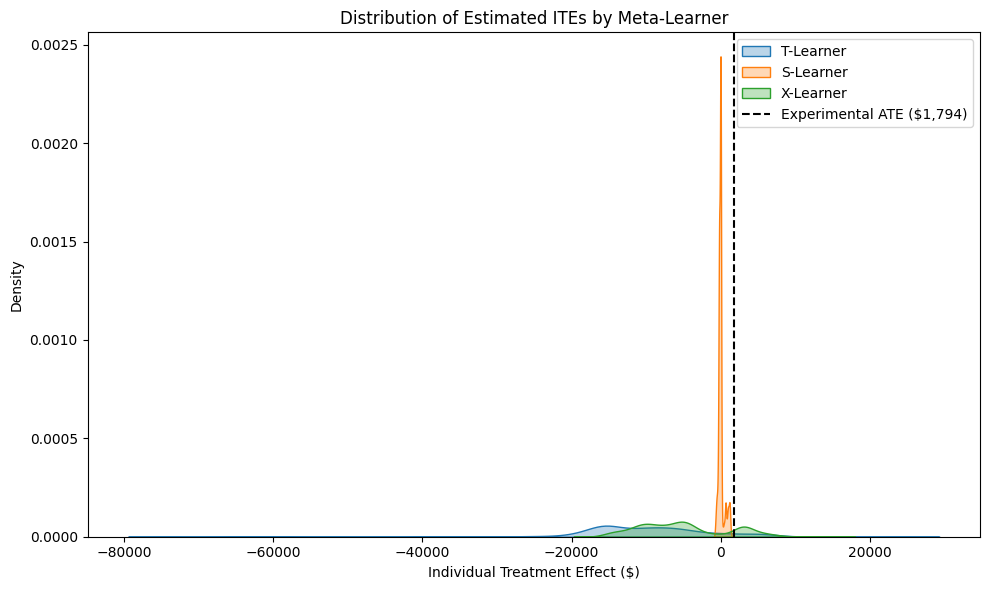

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, ites in ite_df.items():
    sns.kdeplot(ites, ax=ax, label=label, fill=True, alpha=0.3)

ax.axvline(true_ate, color="black", linestyle="--", linewidth=1.5, 
           label=f"Experimental ATE (${true_ate:,.0f})")
ax.set_xlabel("Individual Treatment Effect ($)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Estimated ITEs by Meta-Learner")
ax.legend()
plt.tight_layout()
plt.show()

## Positivity Assumption Check

The positivity (common support) assumption requires that there is overlap in the covariate distributions between treated and control groups. We check this by examining the propensity score distributions.

In [11]:
# Fit propensity score model
ps_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=42))
])
ps_model.fit(X, T)
propensity_scores = ps_model.predict_proba(X)[:, 1]

# Add to dataframe for analysis
data['propensity_score'] = propensity_scores

# Summary statistics by group
ps_summary = data.groupby('treat')['propensity_score'].describe()
print("Propensity Score Distribution by Treatment Group")
print("="*60)
print(ps_summary)
print()

# Check overlap
treated_ps = data[data['treat']]['propensity_score']
control_ps = data[~data['treat']]['propensity_score']

print(f"Treated PS range:  [{treated_ps.min():.4f}, {treated_ps.max():.4f}]")
print(f"Control PS range:  [{control_ps.min():.4f}, {control_ps.max():.4f}]")
print()

# Count observations outside common support
min_overlap = max(treated_ps.min(), control_ps.min())
max_overlap = min(treated_ps.max(), control_ps.max())
treated_outside = ((treated_ps < min_overlap) | (treated_ps > max_overlap)).sum()
control_outside = ((control_ps < min_overlap) | (control_ps > max_overlap)).sum()

print(f"Common support range: [{min_overlap:.4f}, {max_overlap:.4f}]")
print(f"Treated outside common support: {treated_outside} / {len(treated_ps)} ({100*treated_outside/len(treated_ps):.1f}%)")
print(f"Control outside common support: {control_outside} / {len(control_ps)} ({100*control_outside/len(control_ps):.1f}%)")

Propensity Score Distribution by Treatment Group
        count      mean       std           min       25%       50%       75%  \
treat                                                                           
False  2490.0  0.028023  0.098556  1.101667e-23  0.000013  0.000319  0.008592   
True    185.0  0.623202  0.274515  6.615516e-04  0.447365  0.740096  0.853276   

            max  
treat            
False  0.897788  
True   0.921325  

Treated PS range:  [0.0007, 0.9213]
Control PS range:  [0.0000, 0.8978]

Common support range: [0.0007, 0.8978]
Treated outside common support: 24 / 185 (13.0%)
Control outside common support: 1392 / 2490 (55.9%)


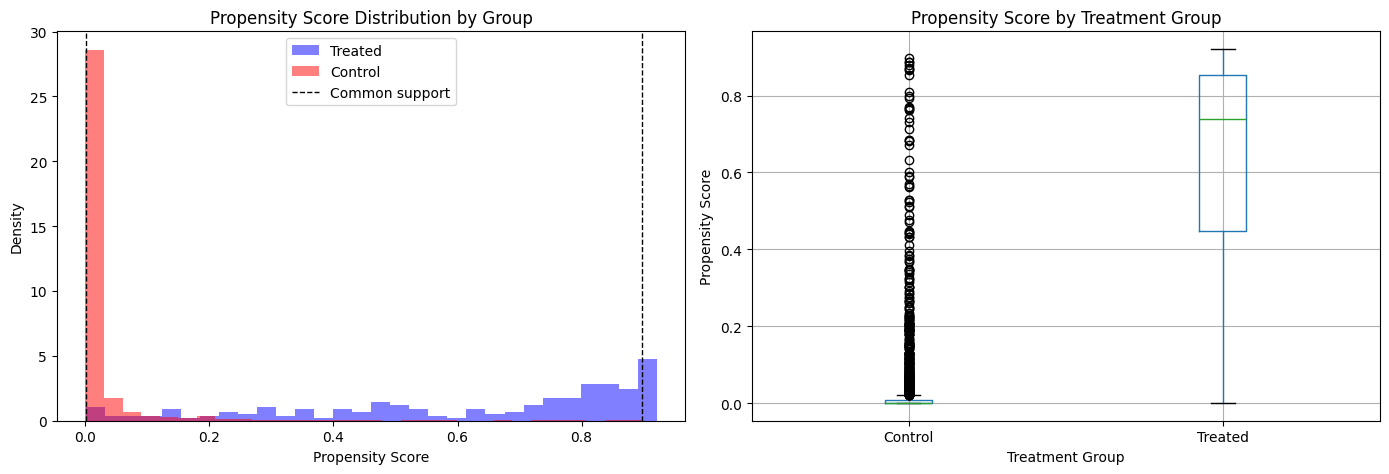

In [12]:
# Visualize propensity score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with overlap
ax = axes[0]
ax.hist(treated_ps, bins=30, alpha=0.5, label='Treated', density=True, color='blue')
ax.hist(control_ps, bins=30, alpha=0.5, label='Control', density=True, color='red')
ax.axvline(min_overlap, color='black', linestyle='--', linewidth=1, label=f'Common support')
ax.axvline(max_overlap, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Distribution by Group')
ax.legend()

# Box plot
ax = axes[1]
data.boxplot(column='propensity_score', by='treat', ax=ax)
ax.set_xlabel('Treatment Group')
ax.set_ylabel('Propensity Score')
ax.set_title('Propensity Score by Treatment Group')
ax.set_xticklabels(['Control', 'Treated'])
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()